In [1]:
import glob
import json
import re
from collections import defaultdict
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib.lines import Line2D
from scipy.integrate import dblquad, quad
from scipy.stats import bootstrap


class Position2:
    def __init__(self, x=0.0, y=0.0):
        self.x = x
        self.y = y

# Experiment Setup

In [2]:
START_POS = Position2(x=450.0, y=300.0)
FIELD_X_MIN = 0.0
FIELD_X_MAX = 900.0

FIELD_Y_MIN = 0.0
FIELD_Y_MAX = 600.0

ROBOT_COLLAPSE_THRESHOLD = 0.5  # cm
OBJECTS_GROUND_TRUTH = {
    "ball": Position2(x=550.0, y=350.0),
    "robot": Position2(x=650.0, y=200.0),
    "X-Intersection": Position2(x=750.0, y=300.0),
    "L-Intersection": Position2(x=800.0, y=450.0),
    "T-Intersection": Position2(x=900.0, y=450.0),
    "goalpost": Position2(x=900.0, y=190.0),
}

# Load Data

In [3]:
def load_ipm_estimations(path, labels=None):
    if labels is None:
        labels = OBJECTS_GROUND_TRUTH.keys()

    estimated = {label: [] for label in labels}

    with open(path, "r") as f:
        data = json.load(f)

        for frame_data in data:
            # Temporary storage
            frame_objects = {label: [] for label in labels}

            for obj in frame_data:
                label = obj["label"]
                if label in frame_objects:
                    pos = Position2(x=obj["field_x"], y=obj["field_y"])
                    robot = Position2(x=obj["robot_x"], y=obj["robot_y"])
                    frame_id = obj["frame"]
                    frame_objects[label].append((pos, robot, frame_id))

            for label, objs in frame_objects.items():
                if not objs:
                    continue

                if len(objs) > 1:
                    gt = OBJECTS_GROUND_TRUTH[label]

                    # Pick closest to ground truth
                    best = min(
                        objs, key=lambda x: np.hypot(x[0].x - gt.x, x[0].y - gt.y)
                    )
                    estimated[label].append(best)
                else:
                    for obj in objs:
                        estimated[label].append(obj)

    return estimated


dynamic_ipm = []
files = sorted(
    glob.glob("../data/dynamic_ipm_logs*.json")
)
print("Dynamic logs count:", len(files))
for filename in files:
    data = load_ipm_estimations(filename, ["ball", "robot", "X-Intersection"])
    dynamic_ipm.append(data)

Dynamic logs count: 10


# IPM Evaluation

### Error Metrices

In [4]:
def euclidean_error(estimated: Position2, actual: Position2, robot: Position2):
    dx = estimated.x - actual.x
    dy = estimated.y - actual.y
    err = np.hypot(dx, dy)

    return err

### Static Evaluation

In [5]:
static_ipm = load_ipm_estimations("../data/static_ipm_logs.json")


def compute_ci(data, metric_func, n_resamples=10000):
    if len(data) <= 0:
        return np.nan, np.nan

    data_arr = np.array(data)
    if np.all(data_arr == data_arr[0]):
        return data_arr[0], data_arr[0]

    res = bootstrap(
        (data_arr,),
        metric_func,
        confidence_level=0.95,
        n_resamples=n_resamples,
        method="percentile",
    )
    return res.confidence_interval.low, res.confidence_interval.high


def mae_func(x):
    return np.mean(x)


def rmse_func(x):
    return np.sqrt(np.mean(np.square(x)))


def std_func(x):
    return np.std(x)


def median_func(x):
    return np.median(x)


def mad_func(x):
    return np.mean(np.abs(x - np.median(x)))


def print_summary_static(title, data, results_dict):
    print(f"=== {title} ===")

    for label, entries in data.items():
        if len(entries) == 0:
            continue

        total_errs = np.array(results_dict[label])
        mae = mae_func(total_errs)
        ci_mae = compute_ci(total_errs, mae_func)

        median = median_func(total_errs)
        ci_median = compute_ci(total_errs, median_func)
        mad = mad_func(total_errs)
        ci_mad = compute_ci(total_errs, mad_func)

        std_dev = std_func(total_errs)
        ci_std = compute_ci(total_errs, std_func)

        rmse = rmse_func(total_errs)
        ci_rmse = compute_ci(total_errs, rmse_func)
        (
            p75,
            p90,
            p95,
        ) = np.percentile(total_errs, [75, 90, 95])

        print(f"{label}:")
        print("  Euclidean Distance Error Metrics:")
        print(f"    MAE        : {mae:.2f}  95% CI: [{ci_mae[0]:.2f}, {ci_mae[1]:.2f}]")
        print(f"    MAD        : {mad:.2f} 95% CI: [{ci_mad[0]:.2f}, {ci_mad[1]:.2f}]")
        print(
            f"    Median     : {median:.2f} 95% CI: [{ci_median[0]:.2f}, {ci_median[1]:.2f}]"
        )
        print(
            f"    STD Dev    : {std_dev:.2f}  95% CI: [{ci_std[0]:.2f}, {ci_std[1]:.2f}]"
        )
        print(
            f"    RMSE       : {rmse:.2f}  95% CI: [{ci_rmse[0]:.2f}, {ci_rmse[1]:.2f}]"
        )
        print(f"    Percentiles: P75={p75:.2f}, P90={p90:.2f}, P95={p95:.2f}")
        print("-" * 45)


def evaluate_static(data):
    metrics_log = defaultdict(list)

    for label, entries in data.items():
        actual = OBJECTS_GROUND_TRUTH[label]
        for est, _, _ in entries:
            err = euclidean_error(est, actual, START_POS)
            metrics_log[label].append(err)

    return metrics_log


static_results = evaluate_static(static_ipm)
print_summary_static("STATIC IPM", static_ipm, static_results)

=== STATIC IPM ===
ball:
  Euclidean Distance Error Metrics:
    MAE        : 1.61  95% CI: [1.52, 1.68]
    MAD        : 0.17 95% CI: [0.09, 0.19]
    Median     : 1.78 95% CI: [1.40, 1.78]
    STD Dev    : 0.19  95% CI: [0.16, 0.19]
    RMSE       : 1.62  95% CI: [1.53, 1.70]
    Percentiles: P75=1.78, P90=1.78, P95=1.78
---------------------------------------------
robot:
  Euclidean Distance Error Metrics:
    MAE        : 6.61  95% CI: [6.42, 6.74]
    MAD        : 0.13 95% CI: [0.00, 0.32]
    Median     : 6.74 95% CI: [6.74, 6.74]
    STD Dev    : 0.40  95% CI: [0.00, 0.58]
    RMSE       : 6.62  95% CI: [6.45, 6.74]
    Percentiles: P75=6.74, P90=6.74, P95=6.74
---------------------------------------------
X-Intersection:
  Euclidean Distance Error Metrics:
    MAE        : 3.33  95% CI: [3.33, 3.33]
    MAD        : 0.00 95% CI: [3.33, 3.33]
    Median     : 3.33 95% CI: [3.33, 3.33]
    STD Dev    : 0.00  95% CI: [3.33, 3.33]
    RMSE       : 3.33  95% CI: [3.33, 3.33]
    Pe

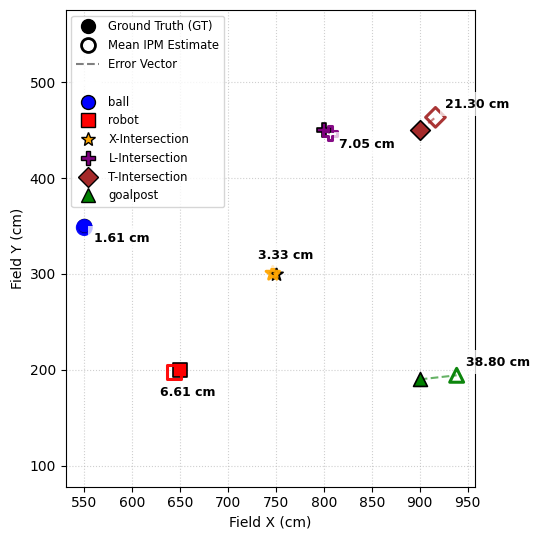

In [20]:
def plot_est_vs_gt_static(static_ipm, static_results, labels=None):
    if labels is None:
        labels = list(static_ipm.keys())
    plt.figure(figsize=(5.5, 5.5))
    # -------------------------------------
    # Colors & Markers
    # -------------------------------------
    color_map = {
        "ball": "blue",
        "robot": "red",
        "goalpost": "green",
        "X-Intersection": "orange",
        "L-Intersection": "purple",
        "T-Intersection": "brown",
    }

    marker_map = {
        "ball": "o",
        "robot": "s",
        "goalpost": "^",
        "X-Intersection": "*",
        "L-Intersection": "P",
        "T-Intersection": "D",
    }

    # -------------------------------------
    # Legend
    # -------------------------------------
    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            linestyle="None",
            label="Ground Truth (GT)",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=10,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            linestyle="None",
            label="Mean IPM Estimate",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=2,
            markersize=10,
        ),
        Line2D([0], [0], color="gray", linestyle="--", label="Error Vector"),
        Line2D([0], [0], color="white", label=" "),
    ]

    # Object Legends
    for label in labels:
        marker = marker_map.get(label, "o")
        color = color_map.get(label, "black")
        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                color=color,
                linestyle="None",
                label=label,
                markerfacecolor=color,
                markeredgecolor="black",
                markersize=10,
            )
        )

    # -------------------------------------
    # Plot Objects
    # -------------------------------------

    for label in labels:
        if label not in static_ipm:
            continue

        gt = OBJECTS_GROUND_TRUTH[label]

        color = color_map.get(label, "black")
        marker = marker_map.get(label, "o")

        avg_x = np.mean([est.x for est, _, _ in static_ipm[label]])
        avg_y = np.mean([est.y for est, _, _ in static_ipm[label]])
        median_x = np.median([est.x for est, _, _ in static_ipm[label]])
        median_y = np.median([est.y for est, _, _ in static_ipm[label]])

        total_errs = np.array(static_results[label])
        mae = mae_func(total_errs)

        offset_x = 10 if (avg_x >= gt.x) else -15
        offset_y = 10 if (avg_y >= gt.y) else -15

        if label == "X-Intersection":
            offset_y = 15
        elif label == "robot":
            offset_y = -25

        # ---------------------------------
        # Ground Truth (Filled)
        # ---------------------------------
        plt.scatter(
            gt.x,
            gt.y,
            marker=marker,
            s=100,
            color=color,
            edgecolors="black",
            linewidths=1.2,
            zorder=3,
        )

        # ---------------------------------
        # Mean Estimate (Hollow)
        # ---------------------------------
        plt.scatter(
            avg_x,
            avg_y,
            marker=marker,
            s=100,
            facecolors="none",
            edgecolors=color,
            linewidths=2.2,
            alpha=0.95,
            zorder=3,
        )
        # plt.scatter(
        #     median_x,
        #     median_y,
        #     marker="+",
        #     s=80,
        #     color=color,
        #     linewidths=2,
        #     alpha=0.9,
        #     zorder=4,
        # )

        # ---------------------------------
        # Error Vector
        # ---------------------------------

        plt.plot(
            np.array([float(gt.x), float(avg_x)]),
            np.array([float(gt.y), float(avg_y)]),
            color=color,
            linestyle="--",
            alpha=0.6,
            linewidth=1.5,
            zorder=2,
        )

        # ---------------------------------
        # Error Text
        # ---------------------------------
        text_x = float(avg_x) + float(offset_x)
        text_y = float(avg_y) + float(offset_y)
        plt.text(
            text_x,
            text_y,
            f"{mae:.2f} cm",
            fontsize=9,
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"),
            zorder=4,
        )

    # -------------------------------------
    # Final Styling
    # -------------------------------------

    plt.xlabel("Field X (cm)")
    plt.ylabel("Field Y (cm)")
    plt.axis("equal")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(
        handles=legend_elements, loc="upper left", fontsize="small", frameon=True
    )
    plt.tight_layout()
    plt.savefig("../figures/static_ipm_evaluation_2.png", bbox_inches="tight")
    plt.show()


plot_est_vs_gt_static(static_ipm, static_results)

### Dynamic Evaluation

In [12]:
def is_estimation_valid(est, robot, frame):
    # estimated point must lie inside field
    if not (FIELD_X_MIN <= est.x <= FIELD_X_MAX):
        return False, "outside_field_x"

    if not (FIELD_Y_MIN <= est.y <= FIELD_Y_MAX):
        return False, "outside_field_y"

    return True, None


def filter_invalid_estimates(runs, exclude_labels=None):
    if exclude_labels is None:
        exclude_labels = []

    filtered_runs = []

    total_samples = 0
    removed_samples = 0

    removed_log = {}

    for trial_idx, run in enumerate(runs, start=1):
        new_run = {}

        for label, entries in run.items():
            if label not in OBJECTS_GROUND_TRUTH:
                continue

            if label in exclude_labels:
                new_run[label] = entries
                continue

            filtered_entries = []

            for est, robot, frame in entries:
                total_samples += 1

                valid, reason = is_estimation_valid(est, robot, frame)

                if valid:
                    filtered_entries.append((est, robot, frame))
                    continue

                removed_samples += 1

                actual = OBJECTS_GROUND_TRUTH[label]
                err = np.hypot(est.x - actual.x, est.y - actual.y)

                removed_log.setdefault(label, []).append(
                    {
                        "trial": trial_idx,
                        "frame": frame,
                        "reason": reason,
                        "est_x": est.x,
                        "est_y": est.y,
                        "robot_x": robot.x,
                        "robot_y": robot.y,
                        "error": err,
                    }
                )

            new_run[label] = filtered_entries

        filtered_runs.append(new_run)

    print("=" * 60)
    print("REMOVED ESTIMATES")
    print("=" * 60)

    for label, removed in removed_log.items():
        print(f"\n{label}: {len(removed)} removed")

        for r in removed:
            print(
                f"  Trial:{r['trial']:2d}, "
                f"Frame:{r['frame']:3d}, "
                f"({r['est_x']:.2f}, {r['est_y']:.2f}) "
                f"-> Error {r['error']:.2f}, "
                f"Reason={r['reason']}"
            )

    print("\n" + "=" * 60)
    print(f"Total samples   : {total_samples}")
    print(f"Removed samples : {removed_samples}")
    if total_samples > 0:
        print(f"Removal percent : {100 * removed_samples / total_samples:.2f}%")
    print("=" * 60)

    return filtered_runs


filtered_dynamic_ipm = filter_invalid_estimates(dynamic_ipm)

REMOVED ESTIMATES

ball: 9 removed
  Trial: 1, Frame: 17, (279.17, 613.60) -> Error 377.94, Reason=outside_field_y
  Trial: 3, Frame: 10, (278.69, 621.31) -> Error 383.69, Reason=outside_field_y
  Trial: 4, Frame:  9, (282.11, 609.15) -> Error 372.73, Reason=outside_field_y
  Trial: 5, Frame: 10, (271.88, 630.46) -> Error 394.98, Reason=outside_field_y
  Trial: 6, Frame:  9, (274.87, 625.04) -> Error 389.03, Reason=outside_field_y
  Trial: 7, Frame: 13, (288.48, 608.35) -> Error 367.61, Reason=outside_field_y
  Trial: 8, Frame: 14, (255.58, 646.29) -> Error 417.70, Reason=outside_field_y
  Trial: 9, Frame: 21, (231.03, 693.32) -> Error 468.62, Reason=outside_field_y
  Trial:10, Frame: 10, (264.47, 637.43) -> Error 405.14, Reason=outside_field_y

robot: 9 removed
  Trial: 1, Frame: 59, (766.64, -6.23) -> Error 236.93, Reason=outside_field_y
  Trial: 1, Frame: 60, (733.89, -93.48) -> Error 305.24, Reason=outside_field_y
  Trial: 3, Frame: 36, (880.05, -359.37) -> Error 604.83, Reason=out

#### Evaluation

In [13]:
def print_summary_dynamic(title, runs, results_dict):
    print(f"=== {title} ===")

    # Get a sorted list of all unique labels across all dynamic runs
    all_labels = sorted(list(results_dict.keys()))

    for label in all_labels:
        total_errs = np.array(results_dict[label])
        if len(total_errs) == 0:
            continue

        # Mean & MAE
        mae = mae_func(total_errs)
        ci_mae = compute_ci(total_errs, mae_func)

        # Median & MAD
        median = np.median(total_errs)
        ci_median = compute_ci(total_errs, median_func)
        mad = np.mean(np.abs(total_errs - median))
        ci_mad = compute_ci(total_errs, mad_func)

        # Standard Deviation
        std_dev = np.std(total_errs)
        ci_std = compute_ci(total_errs, std_func)

        # RMSE
        rmse = rmse_func(total_errs)
        ci_rmse = compute_ci(total_errs, rmse_func)

        # Percentiles
        p75, p90, p95 = np.percentile(total_errs, [75, 90, 95])

        print(f"{label}:")
        print("  Euclidean Distance Error Metrics:")
        print(f"    MAE        : {mae:.2f}  95% CI: [{ci_mae[0]:.2f}, {ci_mae[1]:.2f}]")
        print(
            f"    Median     : {median:.2f} 95% CI: [{ci_median[0]:.2f}, {ci_median[1]:.2f}]"
        )
        print(f"    MAE        : {mae:.2f}  95% CI: [{ci_mae[0]:.2f}, {ci_mae[1]:.2f}]")
        print(f"    MAD        : {mad:.2f} 95% CI: [{ci_mad[0]:.2f}, {ci_mad[1]:.2f}]")
        print(
            f"    STD Dev    : {std_dev:.2f}  95% CI: [{ci_std[0]:.2f}, {ci_std[1]:.2f}]"
        )
        print(
            f"    RMSE       : {rmse:.2f}  95% CI: [{ci_rmse[0]:.2f}, {ci_rmse[1]:.2f}]"
        )
        print(f"    Percentiles: P75={p75:.2f}, P90={p90:.2f}, P95={p95:.2f}")
        print("-" * 45)


def evaluate_dynamic(runs):
    # Dict mapping label -> flat list of error floats compiled across all runs
    metrics_log = defaultdict(list)

    for run in runs:
        for label, entries in run.items():
            if label not in OBJECTS_GROUND_TRUTH:
                continue

            actual = OBJECTS_GROUND_TRUTH[label]

            for est, robot, _ in entries:
                # Uses your new streamlined euclidean_error function
                # Note: 'robot' represents the dynamic robot positions from your loop
                err = euclidean_error(est, actual, robot)
                metrics_log[label].append(err)

    return metrics_log


# Execution
dynamic_results = evaluate_dynamic(filtered_dynamic_ipm)
print_summary_dynamic("DYNAMIC IPM", filtered_dynamic_ipm, dynamic_results)

=== DYNAMIC IPM ===
X-Intersection:
  Euclidean Distance Error Metrics:
    MAE        : 61.05  95% CI: [45.82, 77.27]
    Median     : 5.11 95% CI: [3.69, 8.40]
    MAE        : 61.05  95% CI: [45.82, 77.27]
    MAD        : 58.74 95% CI: [43.66, 74.36]
    STD Dev    : 107.16  95% CI: [92.26, 118.72]
    RMSE       : 123.33  95% CI: [103.72, 141.69]
    Percentiles: P75=36.05, P90=288.68, P95=300.00
---------------------------------------------
ball:
  Euclidean Distance Error Metrics:
    MAE        : 32.08  95% CI: [25.79, 38.90]
    Median     : 12.74 95% CI: [11.83, 13.55]
    MAE        : 32.08  95% CI: [25.79, 38.90]
    MAD        : 25.33 95% CI: [19.48, 31.83]
    STD Dev    : 54.00  95% CI: [41.74, 64.91]
    RMSE       : 62.81  95% CI: [49.30, 75.97]
    Percentiles: P75=25.52, P90=86.10, P95=132.09
---------------------------------------------
robot:
  Euclidean Distance Error Metrics:
    MAE        : 62.16  95% CI: [51.19, 73.70]
    Median     : 14.75 95% CI: [12.10, 17

=== SHAPIRO-WILK NORMALITY TEST RESULTS ===
X-Intersection -> Stat: 0.5756, p-val: 8.1692e-21
ball -> Stat: 0.5424, p-val: 6.0516e-26
robot -> Stat: 0.6558, p-val: 4.5263e-23


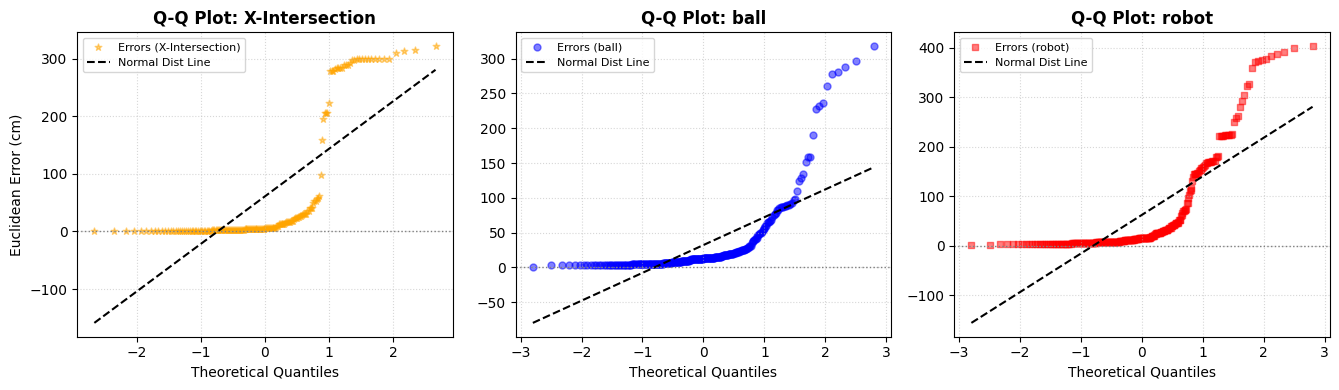

In [14]:
def evaluate_normality_dynamic(results_dict):
    """Performs Shapiro-Wilk test and plots separate Q-Q plots for each object

    using customized colors and markers.
    """
    labels = sorted(list(results_dict.keys()))
    num_objects = len(labels)

    if num_objects == 0:
        print("No data found in results dictionary.")
        return

    # Define your design mappings
    color_map = {
        "ball": "blue",
        "robot": "red",
        "goalpost": "green",
        "X-Intersection": "orange",
        "L-Intersection": "purple",
        "T-Intersection": "brown",
    }

    marker_map = {
        "ball": "o",
        "robot": "s",
        "goalpost": "^",
        "X-Intersection": "*",
        "L-Intersection": "P",
        "T-Intersection": "D",
    }

    fig, axes = plt.subplots(
        1, num_objects, figsize=(4.5 * num_objects, 4), sharey=False
    )

    if num_objects == 1:
        axes = [axes]

    print("=== SHAPIRO-WILK NORMALITY TEST RESULTS ===")

    for idx, label in enumerate(labels):
        total_errs = np.array(results_dict[label])

        if len(total_errs) < 3:
            continue

        # 1. Shapiro-Wilk Test
        stat, p_value = stats.shapiro(total_errs)
        print(f"{label} -> Stat: {stat:.4f}, p-val: {p_value:.4e}")

        ax = axes[idx]

        # 2. Generate the probability plot data without plotting automatically
        (osm, osr), (slope, intercept, r) = stats.probplot(
            total_errs, dist="norm", plot=None
        )

        # Get object-specific styles (default to grey/circle if missing)
        obj_color = color_map.get(label, "grey")
        obj_marker = marker_map.get(label, "o")

        # Plot Data Points manually with your specific style
        ax.scatter(
            osm,
            osr,
            color=obj_color,
            marker=obj_marker,
            s=25,
            alpha=0.5,
            label=f"Errors ({label})",
        )

        # Plot Theoretical Regression Line
        ax.plot(
            osm,
            slope * osm + intercept,
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="Normal Dist Line",
        )
        ax.axhline(0, color="gray", linestyle=":", linewidth=1)

        # Labels & Aesthetics
        ax.set_title(f"Q-Q Plot: {label}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Theoretical Quantiles", fontsize=10)
        if idx == 0:
            ax.set_ylabel("Euclidean Error (cm)", fontsize=10)
        else:
            ax.set_ylabel("", fontsize=10)

        ax.grid(True, linestyle=":", alpha=0.5)
        ax.legend(loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.savefig("../figures/dynamic_errors_qq_plots.png", bbox_inches="tight")
    plt.show()


# Execution syntax:
evaluate_normality_dynamic(dynamic_results)

In [15]:
def summarize_per_run_per_object(runs):
    summary = []

    for i, run in enumerate(runs):
        for label, entries in run.items():
            if label not in OBJECTS_GROUND_TRUTH:
                continue

            actual = OBJECTS_GROUND_TRUTH[label]
            e_list = []

            for est, robot, _ in entries:
                # Use streamlined euclidean_error function
                err = euclidean_error(est, actual, robot)
                e_list.append(err)

            if len(e_list) == 0:
                continue

            total_errs = np.array(e_list)

            # Compute all requested Euclidean metrics for this specific trial-object combo
            mae = mae_func(total_errs)
            ci_mae = compute_ci(total_errs, mae_func)

            # Median & MAD
            median = np.median(total_errs)
            ci_median = compute_ci(total_errs, median_func)
            mad = np.mean(np.abs(total_errs - median))
            ci_mad = compute_ci(total_errs, mad_func)

            std_dev = np.std(total_errs)
            ci_std = compute_ci(total_errs, std_func)

            rmse = rmse_func(total_errs)
            ci_rmse = compute_ci(total_errs, rmse_func)

            p75, p90, p95 = np.percentile(total_errs, [75, 90, 95])

            summary.append(
                {
                    "trial": i + 1,
                    "label": label,
                    "mae": mae,
                    "ci_mae": ci_mae,
                    "median": median,
                    "ci_median": ci_median,
                    "mad": mad,
                    "ci_mad": ci_mad,
                    "std": std_dev,
                    "ci_std": ci_std,
                    "rmse": rmse,
                    "ci_rmse": ci_rmse,
                    "p75": p75,
                    "p90": p90,
                    "p95": p95,
                }
            )

    return summary


def print_summary_per_run_per_object(title, summary):
    print(f"=== {title} ===\n")

    current_trial = None
    for row in summary:
        # Visual divider when switching to a new trial group
        if row["trial"] != current_trial:
            current_trial = row["trial"]
            print(f"\n>>>> TRIAL {current_trial} <<<<")
            print("=" * 45)

        print(f"Object: {row['label']}")
        print("  Euclidean Distance Error Metrics:")
        print(
            f"    MAE        : {row['mae']:.2f}  95% CI: [{row['ci_mae'][0]:.2f}, {row['ci_mae'][1]:.2f}]"
        )
        print(f"    Median     : {row['median']:.2f} 95% CI: [{row['ci_median'][0]:.2f}, {row['ci_median'][1]:.2f}]")
        print(f"    MAD        : {row['mad']:.2f} 95% CI: [{row['ci_mad'][0]:.2f}, {row['ci_mad'][1]:.2f}]")
        print(
            f"    STD Dev    : {row['std']:.2f}  95% CI: [{row['ci_std'][0]:.2f}, {row['ci_std'][1]:.2f}]"
        )
        print(
            f"    RMSE       : {row['rmse']:.2f}  95% CI: [{row['ci_rmse'][0]:.2f}, {row['ci_rmse'][1]:.2f}]"
        )
        print(
            f"    Percentiles: P75={row['p75']:.2f}, P90={row['p90']:.2f}, P95={row['p95']:.2f}"
        )
        print("-" * 45)


# Execution
per_run_summary = summarize_per_run_per_object(filtered_dynamic_ipm)
print_summary_per_run_per_object("DYNAMIC IPM PER RUN", per_run_summary)

=== DYNAMIC IPM PER RUN ===


>>>> TRIAL 1 <<<<
Object: ball
  Euclidean Distance Error Metrics:
    MAE        : 26.28  95% CI: [13.84, 43.92]
    Median     : 8.49 95% CI: [5.25, 17.34]
    MAD        : 21.12 95% CI: [8.63, 37.15]
    STD Dev    : 43.63  95% CI: [14.89, 66.91]
    RMSE       : 50.93  95% CI: [20.51, 79.52]
    Percentiles: P75=26.09, P90=63.30, P95=86.45
---------------------------------------------
Object: robot
  Euclidean Distance Error Metrics:
    MAE        : 50.95  95% CI: [21.25, 87.13]
    Median     : 7.44 95% CI: [6.53, 18.97]
    MAD        : 44.86 95% CI: [15.39, 80.17]
    STD Dev    : 93.13  95% CI: [35.90, 129.69]
    RMSE       : 106.16  95% CI: [42.95, 155.82]
    Percentiles: P75=39.76, P90=183.79, P95=261.42
---------------------------------------------
Object: X-Intersection
  Euclidean Distance Error Metrics:
    MAE        : 20.38  95% CI: [2.91, 53.88]
    Median     : 4.67 95% CI: [1.58, 5.04]
    MAD        : 18.58 95% CI: [1.42, 51.57]
    

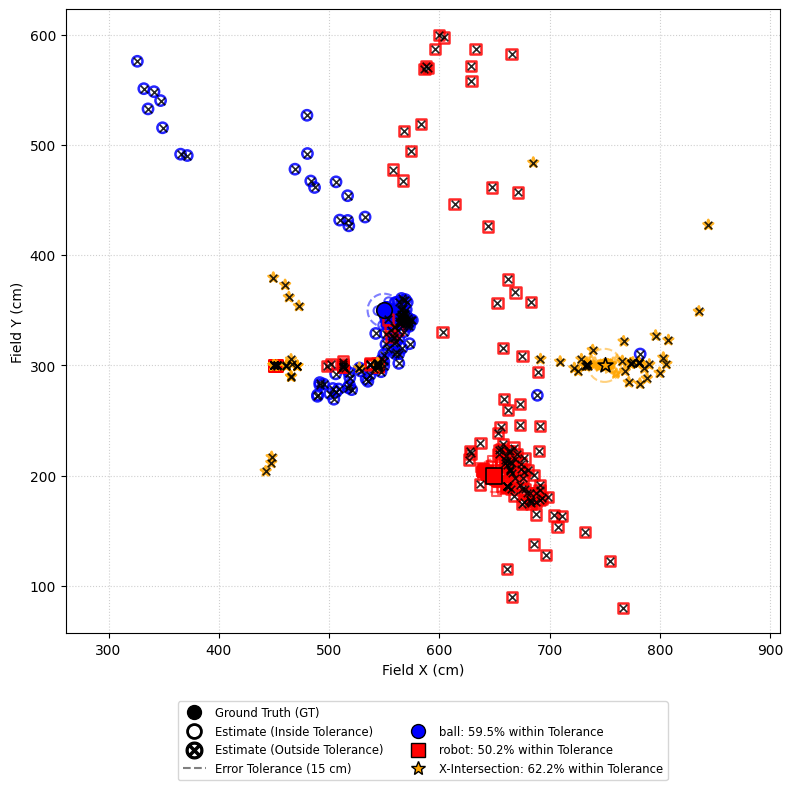

In [15]:
def plot_est_vs_gt_dynamic(dynamic_ipm, labels=None, radius=15):

    if labels is None:
        labels = ["ball", "robot", "X-Intersection"]

    plt.figure(figsize=(8, 8))

    # -------------------------------------
    # Colors
    # -------------------------------------

    color_map = {
        "ball": "blue",
        "robot": "red",
        "goalpost": "green",
        "X-Intersection": "orange",
        "L-Intersection": "purple",
        "T-Intersection": "brown",
    }

    # -------------------------------------
    # Marker Shapes
    # -------------------------------------

    marker_map = {
        "ball": "o",
        "robot": "s",
        "goalpost": "^",
        "X-Intersection": "*",
        "L-Intersection": "P",
        "T-Intersection": "D",
    }

    # -------------------------------------
    # Legend
    # -------------------------------------

    legend_elements = [
        # GT explanation
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            linestyle="None",
            label="Ground Truth (GT)",
            markerfacecolor="black",
            markeredgecolor="black",
            markersize=10,
        ),
        # Estimate inside tolerance
        Line2D(
            [0],
            [0],
            marker="o",
            color="black",
            linestyle="None",
            label="Estimate (Inside Tolerance)",
            markerfacecolor="none",
            markeredgecolor="black",
            markeredgewidth=2,
            markersize=10,
        ),
        # Estimate outside tolerance
        Line2D(
            [0],
            [0],
            marker=r"$\otimes$",
            color="black",
            linestyle="None",
            label="Estimate (Outside Tolerance)",
            markersize=12,
        ),
        # Tolerance circle
        Line2D(
            [0],
            [0],
            color="gray",
            linestyle="--",
            label=f"Error Tolerance ({radius} cm)",
        ),
        # Spacer
        Line2D([0], [0], color="white", label=" "),
    ]

    # -------------------------------------
    # Object Legend
    # -------------------------------------

    for label in labels:
        marker = marker_map.get(label, "o")
        color = color_map.get(label, "black")

        gt = OBJECTS_GROUND_TRUTH[label]

        total = 0
        inside = 0

        for run in dynamic_ipm:
            if label in run:
                for est, _, _ in run[label]:
                    total += 1

                    dx = est.x - gt.x
                    dy = est.y - gt.y

                    err = np.hypot(dx, dy)

                    if err <= radius:
                        inside += 1

        pct_inside = (inside / total) * 100 if total > 0 else 0

        legend_elements.append(
            Line2D(
                [0],
                [0],
                marker=marker,
                color=color,
                linestyle="None",
                label=f"{label}: {pct_inside:.1f}% within Tolerance",
                markerfacecolor=color,
                markeredgecolor="black",
                markersize=10,
            )
        )

    # -------------------------------------
    # Plot Objects
    # -------------------------------------

    for label in labels:
        gt = OBJECTS_GROUND_TRUTH[label]

        color = color_map.get(label, "black")
        marker = marker_map.get(label, "o")

        all_points = []

        for run in dynamic_ipm:
            if label in run:
                all_points.extend(run[label])

        if not all_points:
            continue

        inside_xs, inside_ys = [], []
        outside_xs, outside_ys = [], []

        # ---------------------------------
        # Split Inside / Outside
        # ---------------------------------

        for est, _, _ in all_points:
            dx = est.x - gt.x
            dy = est.y - gt.y

            err = np.hypot(dx, dy)

            if err <= radius:
                inside_xs.append(est.x)
                inside_ys.append(est.y)

            else:
                outside_xs.append(est.x)
                outside_ys.append(est.y)

        # ---------------------------------
        # Ground Truth (Filled)
        # ---------------------------------

        plt.scatter(
            gt.x,
            gt.y,
            marker=marker,
            s=125,
            color=color,
            edgecolors="black",
            linewidths=1.2,
            zorder=5,
        )

        # ---------------------------------
        # Tolerance Circle
        # ---------------------------------

        circle = plt.Circle(
            (gt.x, gt.y),
            radius,
            color=color,
            fill=False,
            linestyle="--",
            linewidth=1.5,
            alpha=0.5,
            zorder=2,
        )

        plt.gca().add_patch(circle)

        # ---------------------------------
        # Inside Tolerance (Hollow)
        # ---------------------------------

        plt.scatter(
            inside_xs,
            inside_ys,
            marker=marker,
            s=40,
            facecolors="none",
            edgecolors=color,
            linewidths=1.5,
            alpha=0.65,
            zorder=3,
        )

        # ---------------------------------
        # Outside Tolerance
        # ---------------------------------

        # Hollow object marker
        plt.scatter(
            outside_xs,
            outside_ys,
            marker=marker,
            s=55,
            facecolors="none",
            edgecolors=color,
            linewidths=1.8,
            alpha=0.85,
            zorder=4,
        )

        # Black X overlay
        plt.scatter(
            outside_xs,
            outside_ys,
            marker="x",
            s=30,
            color="black",
            linewidths=1.2,
            alpha=0.85,
            zorder=5,
        )

    # -------------------------------------
    # Final Styling
    # -------------------------------------

    plt.xlabel("Field X (cm)")
    plt.ylabel("Field Y (cm)")

    plt.axis("equal")

    plt.grid(True, linestyle=":", alpha=0.6)

    plt.legend(
        handles=legend_elements,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.1),  # Places it below the X-axis label
        ncol=2,  # Splitting into 2 or 3 columns shrinks the height
        fontsize="small",
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig("../figures/dynamic_ipm_evaluation_2.png", bbox_inches="tight")
    plt.show()


plot_est_vs_gt_dynamic(filtered_dynamic_ipm, labels=["ball", "robot", "X-Intersection"])

#### Horizon Line Visualization

In [53]:
u_start = 0
v_start = 82.9064

u_end = 320
v_end = 85.3115

horizon_color = (0, 255, 255)
line_thickness = 2

text_color = (255, 255, 0)

image_path = "../docs/static_ipm_camera_view.jpeg"
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image at {image_path}. Make sure the file exists.")
    exit()

start_point = (int(u_start), int(v_start))
end_point = (int(u_end), int(v_end))

cv2.line(img, start_point, end_point, horizon_color, line_thickness)

output_path = "../docs/horizon_visualization.jpeg"
cv2.imwrite(output_path, img)
print(f"Visualization saved to {output_path}")

Visualization saved to ../docs/horizon_visualization.jpeg


#### Numerical Simulation

In [54]:
import numpy as np

fx = 244.15560035753052
fy = 244.6064697061835
cx = 151.04566893941345
cy = 127.51539461608331

R = np.array(
    [
        [0.00193602, -0.174973, 0.984571],
        [-0.999971, -0.00761104, 0.000613707],
        [0.00738623, -0.984544, -0.174982],
    ]
)

t = np.array([0.132858, -0.123182, 0.572371])

W, H = 320, 240

A = R[2, 0] / fx
B = R[2, 1] / fy
C = R[2, 2] - (cx * R[2, 0] / fx) - (cy * R[2, 1] / fy)
line_norm = np.sqrt(A**2 + B**2)


def map_pixel(u, v, sigma=25.0, min_confidence=0.4):
    x = (u - cx) / fx
    y = (v - cy) / fy

    denom = R[2, 0] * x + R[2, 1] * y + R[2, 2]

    if denom >= 0:
        confidence = 0.0
    else:
        # 2. Calculate distance and a clean 0.0 to 1.0 confidence score
        pixel_dist_to_horizon = abs(denom) / line_norm
        confidence = 1.0 - np.exp(-pixel_dist_to_horizon / sigma)

    # 3. Projection Math (Only execute full math if it's a valid, confident point)
    if confidence >= min_confidence:
        status = "Ya"
    else:
        status = "Tidak"

    Zc = -t[2] / denom
    Xc = x * Zc
    Yc = y * Zc
    Pc = np.array([Xc, Yc, Zc])

    Pb = R @ Pc + t
    Xb, Yb, Zb = Pb[0], Pb[1], Pb[2]
    dist = np.hypot(Xb, Yb)

    return (u, v, x, y, Xc, Yc, Zc, Xb, Yb, Zb, dist, status, confidence)


step_u = 10
step_v = 10

u_vals = list(range(0, W, step_u))
v_vals = list(range(0, H, step_v))

grid_w = len(u_vals)
grid_h = len(v_vals)

Y_map = np.zeros((grid_h, grid_w))

results = []

for i_v, v in enumerate(v_vals):
    for i_u, u in enumerate(u_vals):
        res = map_pixel(u, v)
        results.append(res)

results = np.array(results, dtype=object)

# Export data to excel
table_data = []
idx = 0
for i_v, v in enumerate(v_vals):
    for i_u, u in enumerate(u_vals):
        u, v, x, y, Xc, Yc, Zc, Xb, Yb, Zb, dist, status, confidence = results[idx]
        idx += 1

        if status == "Ya":
            Y_map[i_v, i_u] = dist
        else:
            Y_map[i_v, i_u] = np.nan

        table_data.append(
            {
                "(u, v)": f"({u:.0f}, {v:.0f})",
                "(x, y)": f"({x:.2f}, {y:.2f})",
                "Pc (cm)": f"({Xc * 100:.0f}, {Yc * 100:.0f}, {Zc * 100:.0f})",
                "Pb (cm)": f"({Xb * 100:.0f}, {Yb * 100:.0f}, {Zb * 100:.0f})",
                "D (cm)": f"{dist * 100:.0f}",
                "Valid": status,
                "Confidence": confidence,
            }
        )

df = pd.DataFrame(table_data)
# df.to_excel("../data/simulasi_numerik.xlsx", index=False)
print("Data exported to ../data/simulasi_numerik.xlsx")

Data exported to ../data/simulasi_numerik.xlsx


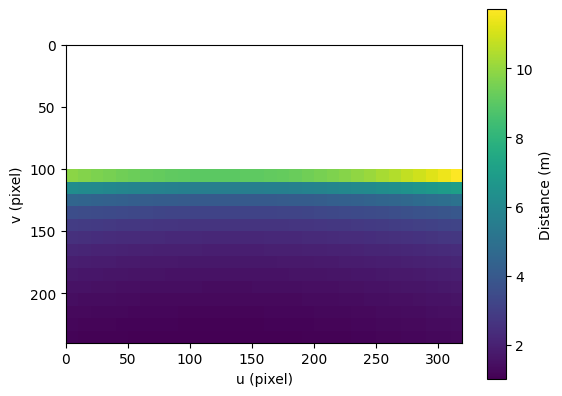

In [55]:
plt.figure()
plt.imshow(Y_map, extent=[0, W, H, 0])
plt.colorbar(label="Distance (m)")
plt.xlabel("u (pixel)")
plt.ylabel("v (pixel)")
plt.show()

#### Odometry Evaluation (Martinelli)

In [21]:
df = pd.read_csv("../data/dynamic_ipm_positions.csv")
n = len(df)

df["delta_x"] = df["estimated_pos_x"] - df["actual_pos_x"]
df["delta_y"] = df["estimated_pos_y"] - df["actual_pos_y"]
df["delta_orientation"] = df["estimated_orientation"] - df["actual_orientation"]

df.head(10)

,estimated_pos_x,estimated_pos_y,actual_pos_x,actual_pos_y,estimated_orientation,actual_orientation,delta_x,delta_y,delta_orientation
0,544.4,301.9,542.5,302.1,-11.5625,-11.5,1.9,-0.2,-0.0625
1,544.4,300.5,543.1,300.7,-0.4375,-0.4,1.3,-0.2,-0.0375
2,544.4,301.0,543.2,301.5,-2.8750,-2.8,1.2,-0.5,-0.0750
3,544.4,299.4,543.1,300.8,0.3125,0.3,1.3,-1.4,0.0125
4,544.4,299.3,543.2,300.5,-0.6875,-0.7,1.2,-1.2,0.0125
5,544.4,298.5,542.8,301.3,-0.8750,-0.8,1.6,-2.8,-0.0750
6,544.4,299.3,542.5,300.2,1.5250,1.5,1.9,-0.9,0.0250
7,544.4,298.4,542.0,299.2,2.9375,2.9,2.4,-0.8,0.0375
8,544.4,302.0,542.6,301.2,-7.7500,-7.6,1.8,0.8,-0.1500
9,544.4,300.5,542.8,302.2,-1.9375,-1.8,1.6,-1.7,-0.1375


In [23]:
rho_target_cm = 100  # Target was 1 meter

# Distance the robot *thinks* it traveled (Encoder Distance)
rho_bar = np.mean(
    np.sqrt(
        (df["estimated_pos_x"] - START_POS.x) ** 2
        + (df["estimated_pos_y"] - START_POS.y) ** 2
    )
)

# Conversions for Calculation (Must be in Radians)
df["actual_rad"] = np.radians(df["actual_orientation"])
df["est_rad"] = np.radians(df["estimated_orientation"])
phi_est = df["est_rad"].mean()

# Compute Observables (Eq. 15-19)
phi_0 = 0.0
phi_1 = df["actual_rad"].mean()
phi_2 = df["actual_rad"].var(ddof=1)
dx = df["actual_pos_x"] - START_POS.x
dy = df["actual_pos_y"] - START_POS.y
phi_3 = np.mean(dx * np.cos(phi_est) + dy * np.sin(phi_est))
phi_5 = ((dx) ** 2 + (dy) ** 2).mean()

# Solve for Parameters (in Radians/CM first)
Er_rad = (phi_1 - phi_est) / rho_bar
K_theta_rad2 = phi_2 / rho_bar


# Solve for Et (Eq. 29)
def integrand_x(s, Er, K_theta):
    return np.cos(phi_0 + Er * s) * np.exp(-K_theta * s / 2.0)


int_val_x, _ = quad(integrand_x, 0, rho_bar, args=(Er_rad, K_theta_rad2))
one_plus_Et = phi_3 / int_val_x
Et = one_plus_Et - 1


# Solve for K_rho (Eq. 32)
def integrand_p5(s_p, s, Er, K_theta):
    return np.exp(-K_theta * s_p / 2.0) * np.cos(phi_0 + Er * s_p)


res_p5_int, _ = dblquad(
    integrand_p5,
    0,
    rho_bar,
    lambda s: 0,
    lambda s: rho_bar - s,
    args=(Er_rad, K_theta_rad2),
)

K_rho = (phi_5 - 2 * (one_plus_Et**2) * res_p5_int) / rho_bar

# Convert units
Er_deg = np.degrees(Er_rad)
K_theta_deg2 = np.degrees(1) ** 2 * K_theta_rad2
Et_percent = Et * 100

print(f"Er: {Er_deg:.4f} deg/cm")
print(f"K_theta: {K_theta_deg2:.4f} deg^2/cm")
print(f"Et: {Et_percent:.4f}%")
print(f"K_rho: {K_rho:.6f} cm")

Er: 0.0005 deg/cm
K_theta: 0.1994 deg^2/cm
Et: -1.6902%
K_rho: 0.042551 cm


# Comparison with Regression Method

In [24]:
df = pd.read_csv("../data/regression_vs_ipm.csv")

# Calculate absolute error
df["regression_error"] = (df["regression"] - df["dist"]).abs()
df["ipm_error"] = (df["ipm"] - df["dist"]).abs()
plt.figure(figsize=(6, 4.5))
plt.plot(df["dist"], df["dist"], "k--", label="Ground Truth (Ideal)", alpha=0.6)
plt.plot(
    df["dist"], df["regression"], "r-o", label="Polynomial Regression", markersize=4
)
plt.plot(df["dist"], df["ipm"], "b-s", label="Proposed IPM", markersize=4)

plt.xlabel("Reference Distance (cm)", fontsize=10)
plt.ylabel("Measured Distance (cm)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/regression_vs_ipm_estimates.png", bbox_inches="tight", dpi=300)
plt.close()

plt.figure(figsize=(6, 4.5))
plt.plot(
    df["dist"], df["regression_error"], "r-o", label="Regression Error", markersize=4
)
plt.plot(df["dist"], df["ipm_error"], "b-s", label="IPM Error", markersize=4)

plt.xlabel("Reference Distance (cm)", fontsize=10)
plt.ylabel("Absolute Error (cm)", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/regression_vs_ipm_error.png", bbox_inches="tight", dpi=300)
plt.close()

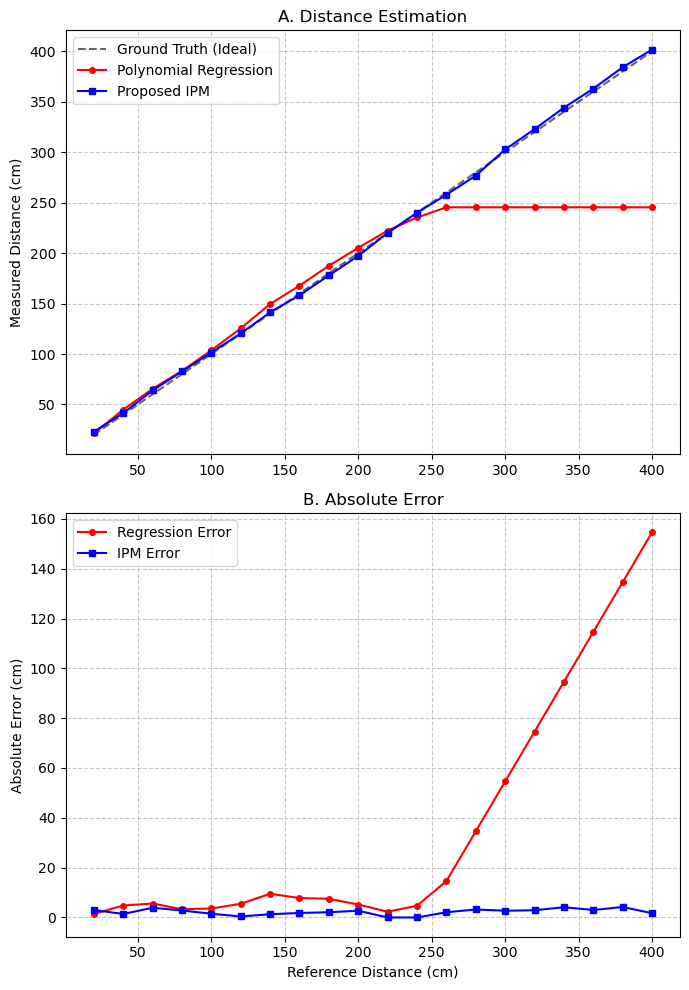

In [25]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10))

ax1.plot(df["dist"], df["dist"], "k--", label="Ground Truth (Ideal)", alpha=0.6)
ax1.plot(
    df["dist"], df["regression"], "r-o", label="Polynomial Regression", markersize=4
)
ax1.plot(df["dist"], df["ipm"], "b-s", label="Proposed IPM", markersize=4)
ax1.set_ylabel("Measured Distance (cm)")
# We can remove the xlabel from the top plot if they share the same axis to save space
ax1.set_title("A. Distance Estimation")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.7)

# --- Plot 2: Absolute Error (Bottom) ---
ax2.plot(
    df["dist"], df["regression_error"], "r-o", label="Regression Error", markersize=4
)
ax2.plot(df["dist"], df["ipm_error"], "b-s", label="IPM Error", markersize=4)
ax2.set_xlabel("Reference Distance (cm)")
ax2.set_ylabel("Absolute Error (cm)")
ax2.set_title("B. Absolute Error")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.7)

# Adjust layout to prevent title/label overlap
plt.tight_layout()
plt.show()

In [25]:
def calculate_comparison_stats(df):
    methods = ["regression", "ipm"]
    results = {}

    for method in methods:
        # Get the absolute error for this method
        error = (df[method] - df["dist"]).abs()

        results[method] = {
            "MAE (cm)": error.mean(),
            "RMSE (cm)": np.sqrt(np.mean(error**2)),
            "Max Error (cm)": error.max(),
            "Std Dev (cm)": error.std(),
        }

    return pd.DataFrame(results).T


# Run the calculation
stats_df = calculate_comparison_stats(df)
print("=== Comparative Statistical Analysis ===")
print(stats_df.round(2))

=== Comparative Statistical Analysis ===
            MAE (cm)  RMSE (cm)  Max Error (cm)  Std Dev (cm)
regression     36.90      61.00           154.6         49.84
ipm             2.24       2.55             4.2          1.24
